In [16]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import pytorch_lightning as pl
from pytorch_lightning import Trainer
import numpy as np
import my_bar
import importlib
importlib.reload(my_bar)

<module 'my_bar' from '/Users/piotrblaszyk/Documents/university/MRIGI/group-project-70006/code/my_bar.py'>

In [2]:
x_sim, y_sim = my_bar.load_simulation_data()
x_exp, y_exp = my_bar.load_experimental_data()

x_numpy shape: (1138, 10)
y_numpy shape: (1138, 2)


In [3]:
assert x_sim.shape[1] == x_exp.shape[1]
assert y_sim.shape[1] == y_exp.shape[1]

In [4]:
x_sim, y_sim, x_exp, y_exp = my_bar.intelligent_resample(x_sim, y_sim, x_exp, y_exp)

In [5]:
x_sim_normalized, x_sim_means, x_sim_stds = my_bar.normalize(x_sim)
y_sim_normalized, y_sim_means, y_sim_stds = my_bar.normalize(y_sim)
x_denormalized = my_bar.denormalize(x_sim_normalized, x_sim_means, x_sim_stds)
y_denormalized = my_bar.denormalize(y_sim_normalized, y_sim_means, y_sim_stds)

x_exp_normalized, x_exp_means, x_exp_stds = my_bar.normalize(x_exp)
y_exp_normalized, y_exp_means, y_exp_stds = my_bar.normalize(y_exp)
x_denormalized = my_bar.denormalize(x_exp_normalized, x_exp_means, x_exp_stds)
y_denormalized = my_bar.denormalize(y_exp_normalized, y_exp_means, y_exp_stds)

In [6]:
if True:
    x_sim = x_sim_normalized
    y_sim = y_sim_normalized
    x_exp = x_exp_normalized
    y_exp = y_exp_normalized

In [7]:
x_train, y_train, x_val, y_val = my_bar.train_validation(x_sim, y_sim)
x_test, y_test = x_exp, y_exp

In [8]:
num_input_dims = x_train.shape[1]
num_output_dims = y_train.shape[1]
sequence_length = 10

x_train_chunked, y_train_chunked = my_bar.chunk_sequence(x_train, y_train, sequence_length)
x_val_chunked, y_val_chunked = my_bar.chunk_sequence(x_val, y_val, sequence_length)
x_test_chunked, y_test_chunked = my_bar.chunk_sequence(x_test, y_test, sequence_length)

print(f"x_train_chunked shape: {x_train_chunked.shape}")
print(f"y_train_chunked shape: {y_train_chunked.shape}")

x_train_chunked shape: (786, 10, 10)
y_train_chunked shape: (786, 2)


In [9]:
train_loader = my_bar.prepare_dataloader(x_train_chunked, y_train_chunked, 16, True)
val_loader = my_bar.prepare_dataloader(x_val_chunked, y_val_chunked, 16, False)
test_loader = my_bar.prepare_dataloader(x_test_chunked, y_test_chunked, 16, False)

In [10]:
for batch in train_loader:
    x_batch, y_batch = batch
    print(x_batch.shape)
    print(y_batch.shape)
    break

torch.Size([16, 10, 10])
torch.Size([16, 2])


In [11]:
# Define the LSTM model
class LSTMModel(pl.LightningModule):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, lr):
        super(LSTMModel, self).__init__()
        self.save_hyperparameters()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.lr = lr

    def forward(self, x):
        # print('forward start')
        # print(x.shape)
        # Pass through LSTM layers
        lstm_out, _ = self.lstm(x)
        # print(lstm_out.shape)
        # Use the last hidden state for prediction
        lstm_last_output = lstm_out[:, -1, :]
        # print(lstm_last_output.shape)
        out = self.fc(lstm_last_output)
        # print(out.shape)
        # print('forward end')
        return out

    def training_step(self, batch, batch_idx):
        # print('training_step start')
        x, y = batch
        y_hat = self.forward(x)
        # print(y.shape)
        # print(y_hat.shape)
        loss = nn.MSELoss()(y_hat, y)
        self.log("train_loss", loss)
        # print('training_step end')
        return loss

    def validation_step(self, batch, batch_idx):
        # print('validation_step start')
        x, y = batch
        y_hat = self.forward(x)
        # print(y.shape)
        # print(y_hat.shape)
        loss = nn.MSELoss()(y_hat, y)
        self.log("val_loss", loss)
        # print('validation_step end')

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

In [12]:
# Initialize the model
input_dim = num_input_dims
hidden_dim = 64
output_dim = num_output_dims
num_layers = 2
learning_rate = 0.001

model = LSTMModel(input_dim, hidden_dim, output_dim, num_layers, learning_rate)
# Train the model
trainer = Trainer(max_epochs=20, logger=True)
trainer.fit(model, train_loader, val_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name | Type   | Params | Mode 
----------------------------------------
0 | lstm | LSTM   | 52.7 K | train
1 | fc   | Linear | 130    | train
----------------------------------------
52.9 K    Trainable params
0         Non-trainable params
52.9 K    Total params
0.211     Total estimated model params size (MB)
2         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


y_pred shape: torch.Size([1129, 2])
y_test shape: torch.Size([1129, 2])
Mean Squared Error (PyTorch): 3e+03
Mean Squared Error (PyTorch): 3.1838e+03


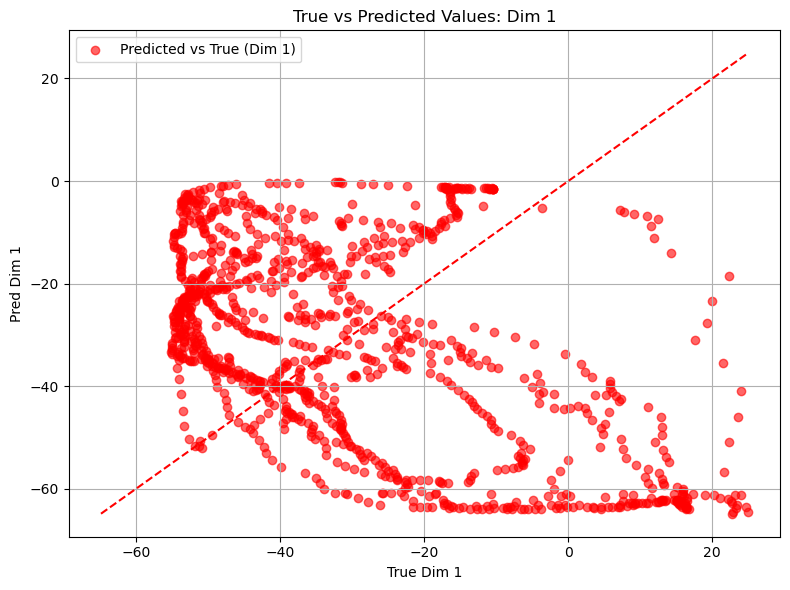

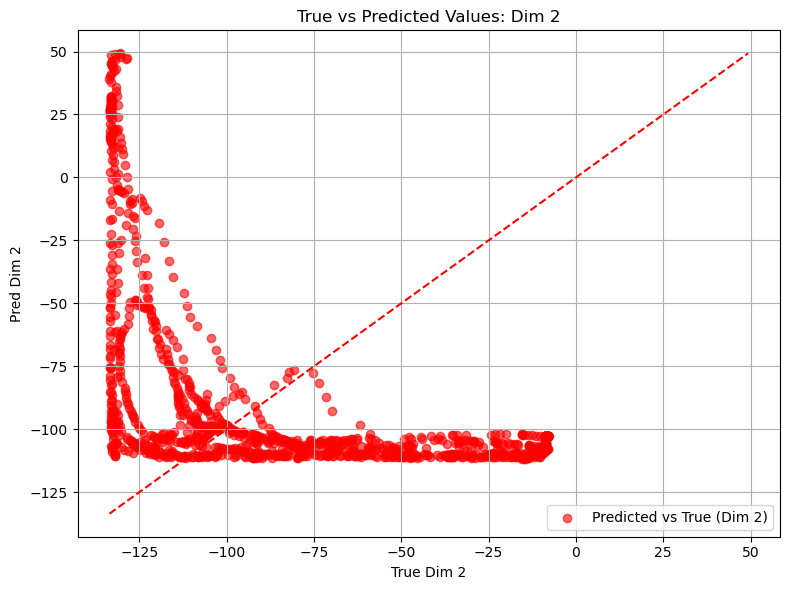

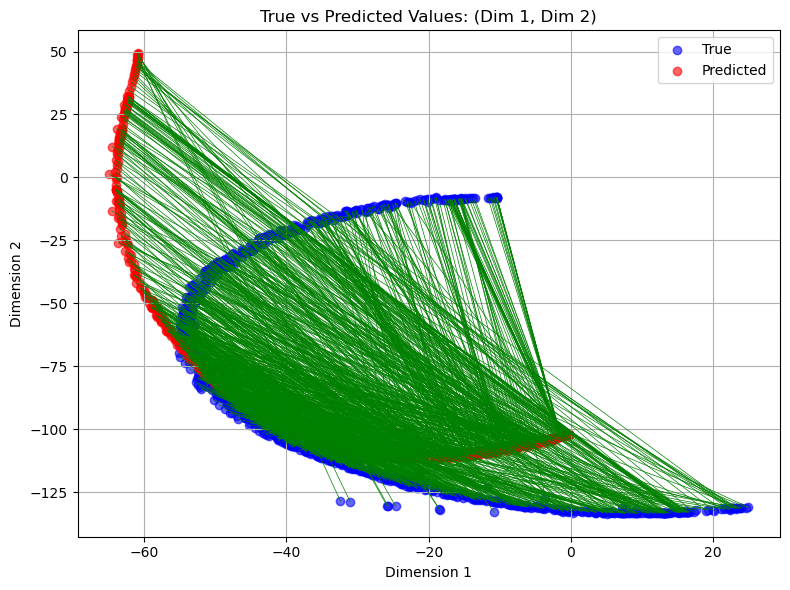

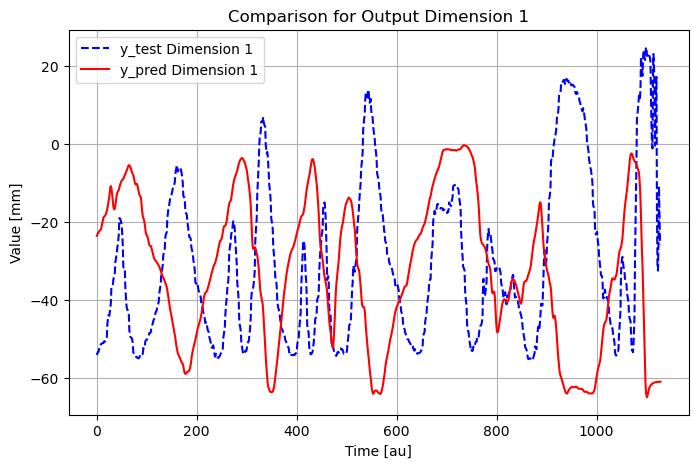

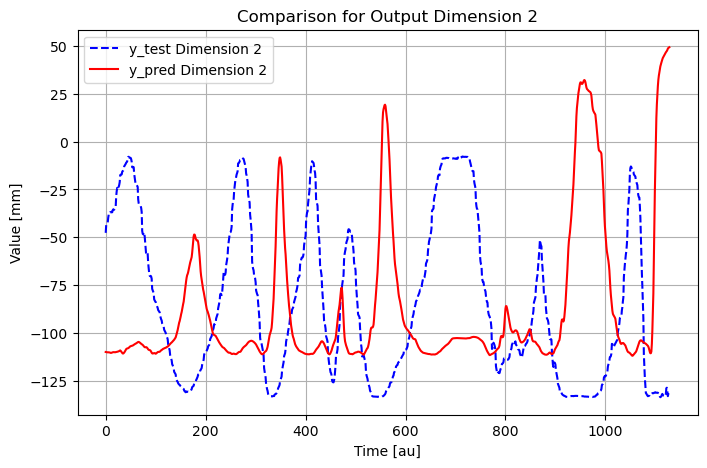

In [17]:
y_test, y_pred = my_bar.test_model(model, test_loader)
y_test_denormalised = my_bar.denormalize(y_test, y_exp_means, y_exp_stds)
y_pred_denormalised = my_bar.denormalize(y_pred, y_exp_means, y_exp_stds)
my_bar.print_mse(y_test_denormalised, y_pred_denormalised)
my_bar.plot_data(y_test_denormalised, y_pred_denormalised)